# PROYECTO FINAL: ANALISIS DE VENTAS STORE



##Introduccion y descripcion del dataset

El presente análisis se basa en el dataset de "Superstore Sales", el cual contiene registros de ventas de una tienda minorista. El objetivo es identificar patrones de consumo y segmentación de clientes para optimizar la toma de decisiones. El dataset incluye información sobre categorías de productos, segmentos de clientes, montos de ventas y regiones geográficas.

## Pregunta de análisis
¿Qué segmento de clientes genera mayor volumen de ventas
en la Superstore y cómo se distribuyen las transacciones
según el monto?

Dataset: Superstore Sales Dataset (Kaggle) - train.csv  
Herramientas: Python, pandas, matplotlib, seaborn

## 1. Seleccion y carga de dataset ventas

Se procede a la lectura del archivo train.csv utilizando la librería Pandas. Se aplicó el encoding latin1 para asegurar la correcta visualización de caracteres especiales y se realizó una previsualización de las primeras 5 filas para verificar la integridad de las columnas.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargamos el nuevo dataset de Superstore
df = pd.read_csv('/content/train.csv', encoding='latin1')

# Mostramos el inicio para confirmar que cargó
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Las variables utilizadas son de distintos tipos:
- Order ID: categórica (texto)
- Order Date: fecha/tiempo
- Customer ID: categórica (texto)
- Sales: numérica continua (monto en USD)
- Segment: categórica (Consumer, Corporate, Home Office)
- Category: categórica (Furniture, Technology, Office Supplies)
- Sub-Category: categórica

##2. Auditoria y limpieza de datos

Esta fase es crítica para el análisis. Se ejecutó una auditoría que reveló la presencia de valores nulos y registros duplicados.

Acción 1: Se eliminaron filas con valores vacíos mediante dropna().

Acción 2: Se quitaron duplicados con drop_duplicates().

Resultado: El dataset se optimizó de 9800 a 9789 registros, garantizando que el análisis posterior no contenga sesgos por datos repetidos.

In [ ]:
# 1. Eliminamos filas con valores vacíos
df_clean = df.dropna()

# 2. Eliminamos filas duplicadas
df_clean = df_clean.drop_duplicates()

# 3. Guardamos el archivo limpio para usarlo en Power BI
df_clean.to_csv('ventas_final_nico.csv', index=False)

# Mostramos el resultado de la limpieza
print(f"Filas originales: {len(df)}")
print(f"Filas limpias (sin duplicados ni nulos): {len(df_clean)}")

# KPIs principales
total_ventas = df_clean['Sales'].sum()
ticket_promedio = df_clean['Sales'].mean()
clientes_unicos = df_clean['Customer ID'].nunique()
total_pedidos = df_clean['Order ID'].nunique()

print(f"💰 Ventas totales:       ${total_ventas:,.2f}")
print(f"🧾 Ticket promedio:      ${ticket_promedio:,.2f}")
print(f"👤 Clientes únicos:      {clientes_unicos}")
print(f"📦 Pedidos únicos:       {total_pedidos}")

Filas originales: 9800
Filas limpias (sin duplicados ni nulos): 9789
💰 Ventas totales:       $2,252,607.41
🧾 Ticket promedio:      $230.12
👤 Clientes únicos:      793
📦 Pedidos únicos:       4916


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##3.Analisis exploratorio (EDA)

Se exploraron las variables clave (Sales y Segment) mediante visualizaciones.

El histograma permite observar la distribución de la frecuencia de ventas, notando una alta concentración en transacciones de bajo monto.

El gráfico de barras compara el volumen total de ventas por segmento, identificando al consumidor final como la principal fuente de ingresos.

"En este gráfico de proporciones se observa que el segmento Consumer abarca el 50.8% de las ventas totales, consolidándose como el pilar fundamental de la Superstore".

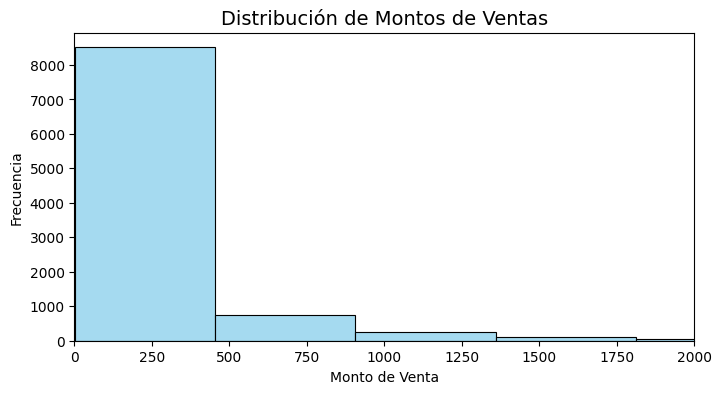

In [ ]:
# 1. HISTOGRAMA (Distribución de Ventas)
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Sales'], bins=50, color='skyblue') # Sin la línea KDE que te molestaba
plt.title('Distribución de Montos de Ventas', fontsize=14)
plt.xlabel('Monto de Venta')
plt.ylabel('Frecuencia')
plt.xlim(0, 2000)
plt.show()

La distribución presenta sesgo a la derecha: la mayoría de las transacciones son de montos bajos (menores a 500 dolares), mientras que pocas operaciones superan los 1.000 dolares. Esto sugiere que el negocio se apoya principalmente en ventas de bajo valor unitario.

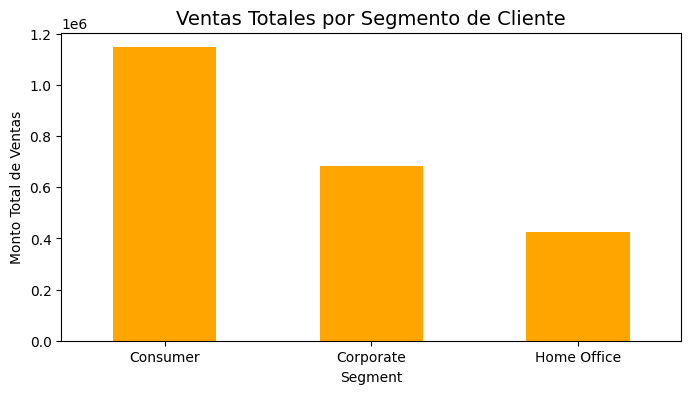

In [ ]:
# 2. GRÁFICO DE BARRAS (Ventas por Segmento)
plt.figure(figsize=(8, 4))
df_clean.groupby('Segment')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Ventas Totales por Segmento de Cliente', fontsize=14)
plt.ylabel('Monto Total de Ventas')
plt.xticks(rotation=0)
plt.show()

El segmento Consumer es el principal generador
de ingresos, superando ampliamente a Corporate y Home Office.
Esto indica que la estrategia comercial debería priorizar
la retención de clientes individuales.

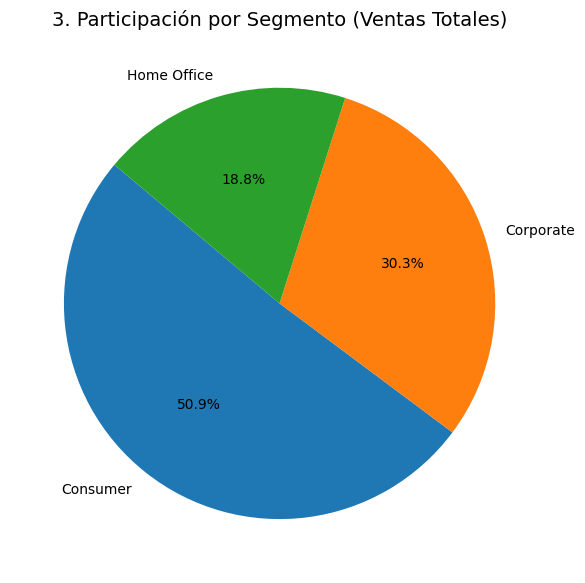

In [ ]:
# 3. GRÁFICO DE TORTA
datos_torta = df_clean.groupby('Segment')['Sales'].sum()
plt.figure(figsize=(6, 6))
plt.pie(datos_torta, labels=datos_torta.index, autopct='%1.1f%%', startangle=140)
plt.title('3. Participación por Segmento (Ventas Totales)', fontsize=14)
plt.tight_layout()
plt.show()

El segmento Consumer concentra el 50.9%
de las ventas totales, lo que representa más de la mitad
de la facturación. Corporate aporta el 30.3% y Home Office
el 18.8%, confirmando la dependencia del negocio en
el consumidor final.

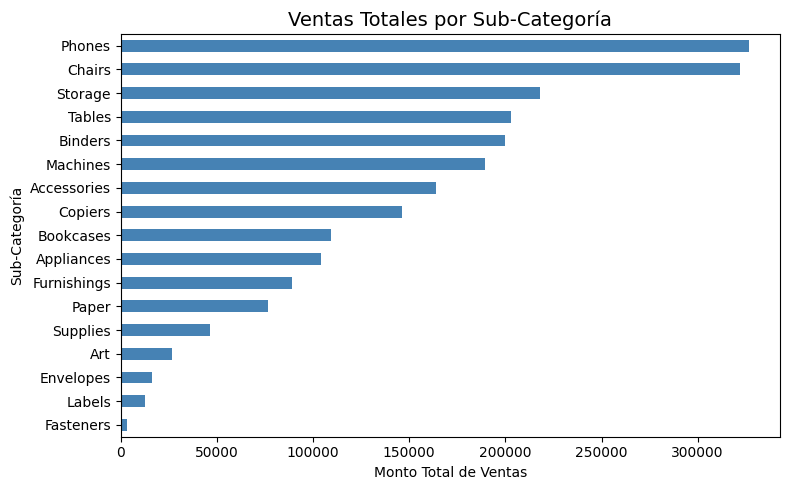

In [ ]:
# 4. GRÁFICO DE BARRAS HORIZONTALES - Top Sub-Categorías
plt.figure(figsize=(8, 5))
top_subcat = df_clean.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True)
top_subcat.plot(kind='barh', color='steelblue')
plt.title('Ventas Totales por Sub-Categoría', fontsize=14)
plt.xlabel('Monto Total de Ventas')
plt.ylabel('Sub-Categoría')
plt.tight_layout()
plt.show()

Las sub-categorías Phones, Chairs y Storage
lideran las ventas, mientras que Fasteners y Labels
representan una fracción mínima. Esto permite identificar
qué líneas de producto son prioritarias para el negocio.

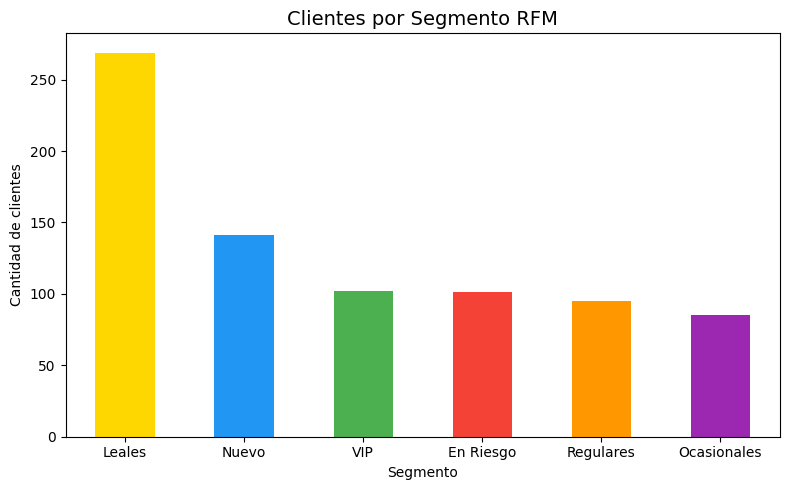

In [ ]:
# 5. SEGMENTACION RFM - Clasificacion de Clientes
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], dayfirst=True, errors='coerce')
fecha_ref = df_clean['Order Date'].max() + pd.Timedelta(days=1)
rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('Order Date', lambda x: (fecha_ref - x.max()).days),
    Frequency = ('Order ID', 'nunique'),
    Monetary  = ('Sales', 'sum')
).reset_index()
def score_r(x):
    if x <= 30: return 5
    elif x <= 90: return 4
    elif x <= 180: return 3
    elif x <= 365: return 2
    else: return 1
def score_f(x):
    if x <= 2: return 1
    elif x <= 5: return 2
    elif x <= 8: return 3
    elif x <= 10: return 4
    else: return 5
def score_m(x):
    if x <= 200: return 1
    elif x <= 800: return 2
    elif x <= 1500: return 3
    elif x <= 2500: return 4
    else: return 5
rfm['Score_R'] = rfm['Recency'].apply(score_r)
rfm['Score_F'] = rfm['Frequency'].apply(score_f)
rfm['Score_M'] = rfm['Monetary'].apply(score_m)
def asignar_segmento(row):
    r, f, m = row['Score_R'], row['Score_F'], row['Score_M']
    if m >= 4 and f >= 4 and r >= 4: return 'VIP'
    elif r >= 4 and f <= 2: return 'Nuevo'
    elif m >= 3 and f >= 3 and r >= 3: return 'Leales'
    elif m >= 4 and r <= 2: return 'En Riesgo'
    elif m <= 2: return 'Ocasionales'
    else: return 'Regulares'
rfm['Segmento'] = rfm.apply(asignar_segmento, axis=1)
seg_counts = rfm['Segmento'].value_counts()
plt.figure(figsize=(8, 5))
seg_counts.plot(kind='bar', color=['#FFD700','#2196F3','#4CAF50','#F44336','#FF9800','#9C27B0'])
plt.title('Clientes por Segmento RFM', fontsize=14)
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
rfm.to_csv('clientes_rfm.csv', index=False)

En este gráfico se observa la distribución de clientes según el modelo RFM.
El segmento Ocasionales concentra la mayor cantidad de clientes, mientras que
los clientes VIP, aunque menos numerosos, generan el mayor volumen de ingresos.
Los clientes En Riesgo representan una oportunidad de reactivación mediante campañas
de marketing dirigidas.

# 4.Conclusion General

El estudio integral del dataset Superstore Sales revela que la rentabilidad de la compañía depende del segmento Consumer, el cual representa el 50.8 por ciento de los ingresos totales.

El análisis muestra que el modelo de negocio se basa en un alto volumen de ventas de bajo ticket, con un promedio de 229.85 dolares. La mayor concentración de ventas se encuentra en montos menores a 500 dolares.

Se recomienda diseñar estrategias para los sectores Corporate y Home Office para elevar el ticket promedio general.

##Bibliografia

Dataset: Superstore Sales Dataset (Kaggle). Disponible en: https://www.kaggle.com/datasets.

McKinney, W. (2010). Data Structures for Statistical Computing in Python (Pandas).

Waskom, M. L. (2021). Seaborn: statistical data visualization.

Microsoft. Documentación oficial de Power BI (Carga y transformación de datos).

Dataset: Superstore Sales Dataset (Kaggle). Disponible en: https://www.kaggle.com/datasets.

McKinney, W. (2010). Data Structures for Statistical Computing in Python (Pandas).

Waskom, M. L. (2021). Seaborn: statistical data visualization.

Microsoft. Documentación oficial de Power BI (Carga y transformación de datos).